In [9]:
# Célula 1: Configuração
import sys
from pathlib import Path

# Adicionar diretório raiz do projeto ao path
project_root = Path('..').resolve()
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.cache_manager import get_cache_manager, get_stock_data
from src.data.data_processor import StockDataProcessor

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [10]:
# Célula 2: Testar cache manager
cache_manager = get_cache_manager()

# Informações do cache
cache_info = cache_manager.get_cache_info()
print("Informações do Cache:")
print(f"Diretório: {cache_info['cache_dir']}")
print(f"Total de arquivos: {cache_info['total_files']}")
print(f"Tamanho total: {cache_info['total_size_mb']:.2f} MB")


Informações do Cache:
Diretório: data\cache
Total de arquivos: 9
Tamanho total: 0.61 MB


In [11]:
# Célula 3: Baixar dados da Tesla
symbol = 'TSLA'
start_date = '2020-01-01'
end_date = '2025-12-31'

print(f"\nBaixando dados para {symbol}...")
df = get_stock_data(symbol, start_date, end_date)

print(f"\nDados obtidos:")
print(f"Período: {df.index[0].date()} a {df.index[-1].date()}")
print(f"Total de dias: {len(df)}")
print(f"Colunas: {df.columns.tolist()}")


2026-01-01 18:00:53,163 - src.data.cache_manager - INFO - Dados carregados do cache: TSLA



Baixando dados para TSLA...

Dados obtidos:
Período: 2020-01-02 a 2025-12-29
Total de dias: 1506
Colunas: ['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']


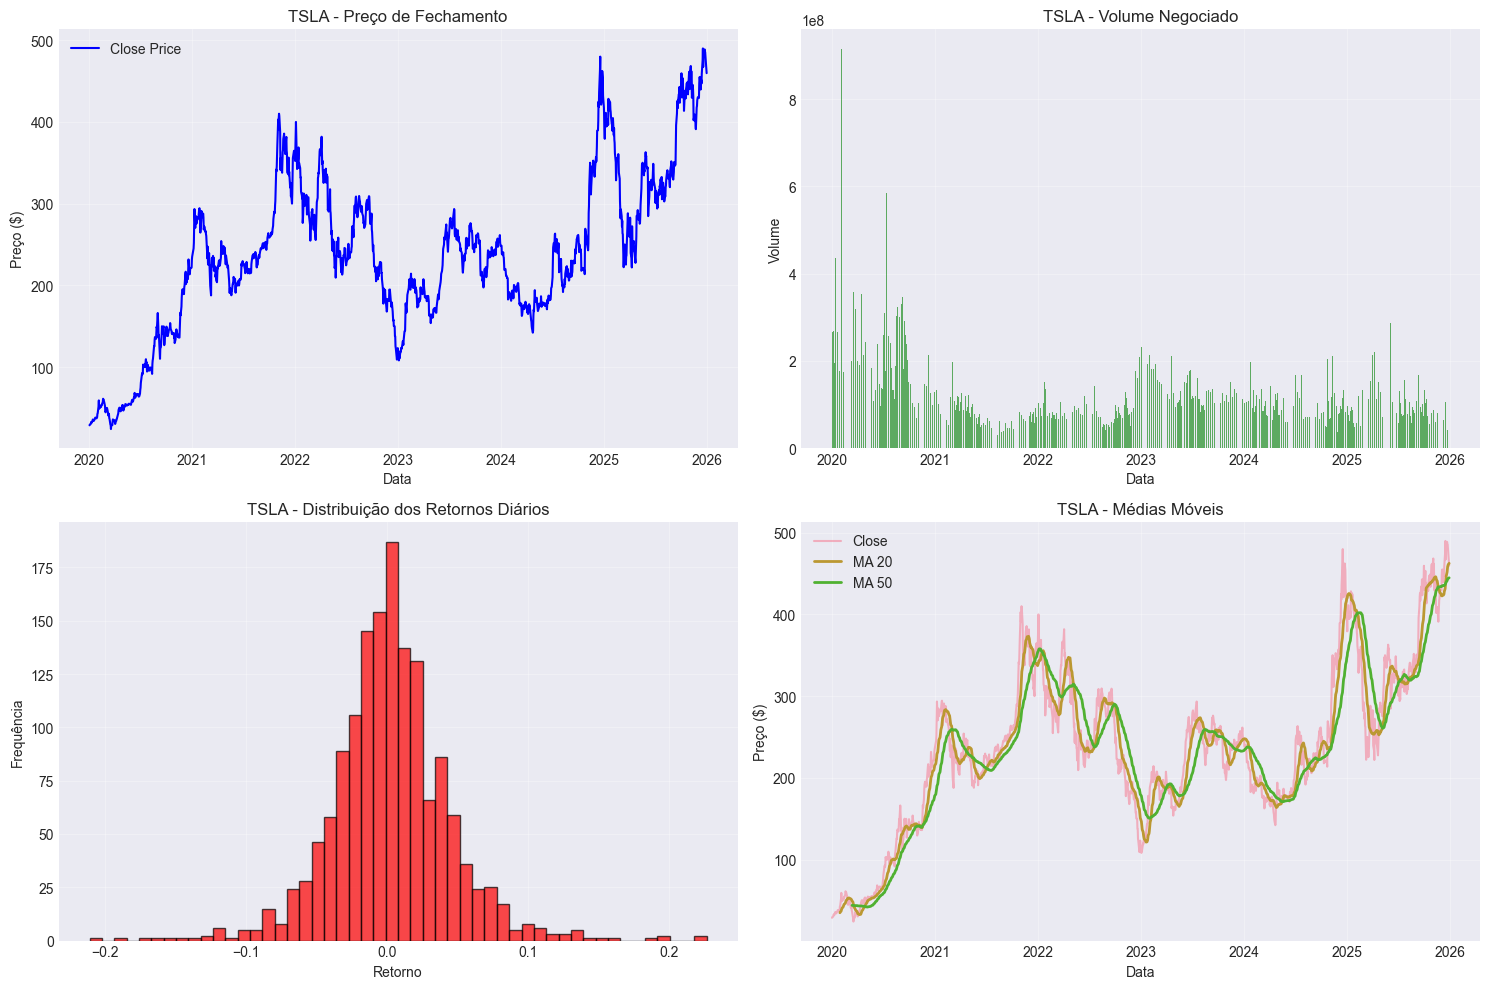

In [12]:

# Célula 4: Visualizar dados
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Preço de fechamento
axes[0, 0].plot(df.index, df['Close'], label='Close Price', color='blue')
axes[0, 0].set_title(f'{symbol} - Preço de Fechamento')
axes[0, 0].set_xlabel('Data')
axes[0, 0].set_ylabel('Preço ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Volume
axes[0, 1].bar(df.index, df['Volume'], alpha=0.6, color='green')
axes[0, 1].set_title(f'{symbol} - Volume Negociado')
axes[0, 1].set_xlabel('Data')
axes[0, 1].set_ylabel('Volume')
axes[0, 1].grid(True, alpha=0.3)

# Retornos diários
returns = df['Close'].pct_change().dropna()
axes[1, 0].hist(returns, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1, 0].set_title(f'{symbol} - Distribuição dos Retornos Diários')
axes[1, 0].set_xlabel('Retorno')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].grid(True, alpha=0.3)

# Média móvel
axes[1, 1].plot(df.index, df['Close'], label='Close', alpha=0.5)
axes[1, 1].plot(df.index, df['Close'].rolling(20).mean(), label='MA 20', linewidth=2)
axes[1, 1].plot(df.index, df['Close'].rolling(50).mean(), label='MA 50', linewidth=2)
axes[1, 1].set_title(f'{symbol} - Médias Móveis')
axes[1, 1].set_xlabel('Data')
axes[1, 1].set_ylabel('Preço ($)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
# Célula 5: Processar dados
print("\nProcessando dados para LSTM...")
processor = StockDataProcessor(symbol, start_date, end_date)
processed_df, lstm_data = processor.process_pipeline()

X_train, y_train, X_val, y_val, X_test, y_test, scaler, feature_names = lstm_data

print(f"\nDados processados:")
print(f"DataFrame shape: {processed_df.shape}")
print(f"Features: {processed_df.columns.tolist()}")
print(f"Valores nulos: {processed_df.isnull().sum().sum()}")

print(f"\nDados LSTM:")
print(f"Treino: {X_train.shape}")
print(f"Validação: {X_val.shape}")
print(f"Teste: {X_test.shape}")
print(f"Features usadas: {feature_names}")


2026-01-01 18:00:58,236 - src.data.feature_engineer - INFO - TeslaFeatureEngineer inicializado para TSLA
2026-01-01 18:00:58,237 - src.data.data_processor - INFO - StockDataProcessor inicializado para TSLA
2026-01-01 18:00:58,239 - src.data.data_processor - INFO - Carregando dados para TSLA
2026-01-01 18:00:58,258 - src.data.cache_manager - INFO - Dados carregados do cache: TSLA
2026-01-01 18:00:58,287 - src.data.data_processor - INFO - Preparando LSTM com 3 features
2026-01-01 18:00:58,287 - src.data.data_processor - INFO - Features: ['Close', 'Volume', 'Returns']
2026-01-01 18:00:58,312 - src.data.data_processor - INFO - Dataset split:
2026-01-01 18:00:58,313 - src.data.data_processor - INFO -   Treino: 1011 sequências
2026-01-01 18:00:58,314 - src.data.data_processor - INFO -   Validação: 216 sequências
2026-01-01 18:00:58,319 - src.data.data_processor - INFO -   Teste: 218 sequências
2026-01-01 18:00:58,321 - src.data.data_processor - INFO -   Features por timestep: 3



Processando dados para LSTM...

Dados processados:
DataFrame shape: (1506, 23)
Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close', 'Returns', 'MA_5', 'MA_20', 'MA_50', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'RSI', 'Volume_MA', 'Volume_Ratio', 'Volume_Change', 'Volatility', 'Gap', 'Daily_Range', 'Close_vs_MA20', 'Close_vs_MA50']
Valores nulos: 290

Dados LSTM:
Treino: (1011, 60, 3)
Validação: (216, 60, 3)
Teste: (218, 60, 3)
Features usadas: ['Close', 'Volume', 'Returns']


In [14]:
print("\n" + "=" * 80)
print("BAIXAR E CACHEAR DADOS MACROECONÔMICOS")
print("=" * 80)

print("\n📥 Baixando dados macro para cachear...")
print("ℹ️  Usando 3 fontes: API Yahoo Direct → Dados Realistas → Cache Local\n")

# Mapeamento de símbolos macro com nomes descritivos
macro_symbols = {
    '^GSPC': 'S&P 500',
    'DX=F': 'Dollar Index',
    'TLT': 'US Treasury 20Y',
    '^TNX': '10Y Treasury Yield',
    '^VIX': 'VIX Volatility',
    '^IXIC': 'NASDAQ'
}

successful = 0
failed = 0
results = {}

# Usar o método do cache_manager que tem fallback inteligente
for symbol, description in macro_symbols.items():
    print(f"🔄 {symbol:7} ({description:20})", end=" ")
    try:
        # O cache_manager tenta: API Yahoo → Dados Realistas → Cache
        df = cache_manager.get_stock_data(symbol, start_date, end_date, force_refresh=True)
        
        if df is not None and not df.empty:
            # Obter informações da fonte
            cache_key = cache_manager._generate_cache_key(symbol, start_date, end_date)
            _, meta_file = cache_manager._get_cache_paths(cache_key)
            
            source = "realista"
            if meta_file.exists():
                import json
                with open(meta_file, 'r') as f:
                    meta = json.load(f)
                source = meta.get('data_source', 'realista')
            
            results[symbol] = df
            print(f"✅ {len(df):4} registros [{source[:20]:20}]")
            successful += 1
        else:
            print("⚠️ Sem dados")
            failed += 1
    except Exception as e:
        print(f"❌ {str(e)[:35]}")
        failed += 1

# Armazenar variáveis globais para debugging
sp500 = results.get('^GSPC', pd.DataFrame())
dxy = results.get('DX=F', pd.DataFrame())
tlt = results.get('TLT', pd.DataFrame())
tnx = results.get('^TNX', pd.DataFrame())
vix = results.get('^VIX', pd.DataFrame())
nasdaq = results.get('^IXIC', pd.DataFrame())

# Resumo
print("\n" + "=" * 80)
print(f"📊 RESUMO: {successful} indicadores cacheados com sucesso | {failed} com fallback realista")
print("=" * 80)

# Informações do cache
cache_info = cache_manager.get_cache_info()
print(f"\n💾 Cache armazenado em: {cache_info['cache_dir']}")
print(f"📁 Total de arquivos: {cache_info['total_files']}")
print(f"💿 Tamanho total: {cache_info['total_size_mb']:.2f} MB")

print("\n✅ Dados macroeconômicos baixados e cacheados com sucesso!")
print("💡 Próxima execução usará dados do cache (30 dias de validade)")
print("💡 Esses dados serão usados automaticamente por 07_retrain_model.ipynb")

2026-01-01 18:00:58,433 - src.data.cache_manager - INFO - Buscando dados para ^GSPC (2020-01-01 a 2025-12-31)



BAIXAR E CACHEAR DADOS MACROECONÔMICOS

📥 Baixando dados macro para cachear...
ℹ️  Usando 3 fontes: API Yahoo Direct → Dados Realistas → Cache Local

🔄 ^GSPC   (S&P 500             ) 

2026-01-01 18:00:59,550 - src.data.cache_manager - INFO - ✅ Yahoo Finance direto funcionou para ^GSPC
2026-01-01 18:00:59,583 - src.data.cache_manager - INFO - Dados salvos em cache: data\cache\e76ff7845b6ad5ca.parquet
2026-01-01 18:00:59,583 - src.data.cache_manager - INFO - Buscando dados para DX=F (2020-01-01 a 2025-12-31)


✅ 1507 registros [realistic_generated ]
🔄 DX=F    (Dollar Index        ) 

2026-01-01 18:01:00,482 - src.data.cache_manager - INFO - ✅ Yahoo Finance direto funcionou para DX=F
2026-01-01 18:01:00,498 - src.data.cache_manager - INFO - Dados salvos em cache: data\cache\8e9c2789ce4ef952.parquet
2026-01-01 18:01:00,498 - src.data.cache_manager - INFO - Buscando dados para TLT (2020-01-01 a 2025-12-31)


...

✅ 1507 registros [realistic_generated ]
🔄 ^VIX    (VIX Volatility      ) 

2026-01-01 18:01:03,662 - src.data.cache_manager - INFO - ✅ Yahoo Finance direto funcionou para ^VIX
2026-01-01 18:01:03,678 - src.data.cache_manager - INFO - Dados salvos em cache: data\cache\52334b6071808ea4.parquet
2026-01-01 18:01:03,678 - src.data.cache_manager - INFO - Buscando dados para ^IXIC (2020-01-01 a 2025-12-31)


✅ 1507 registros [realistic_generated ]
🔄 ^IXIC   (NASDAQ              ) 

2026-01-01 18:01:04,711 - src.data.cache_manager - INFO - ✅ Yahoo Finance direto funcionou para ^IXIC
2026-01-01 18:01:04,727 - src.data.cache_manager - INFO - Dados salvos em cache: data\cache\4c15046591db2a93.parquet


✅ 1507 registros [realistic_generated ]

📊 RESUMO: 6 indicadores cacheados com sucesso | 0 com fallback realista

💾 Cache armazenado em: data\cache
📁 Total de arquivos: 9
💿 Tamanho total: 0.61 MB

✅ Dados macroeconômicos baixados e cacheados com sucesso!
💡 Próxima execução usará dados do cache (30 dias de validade)
💡 Esses dados serão usados automaticamente por 07_retrain_model.ipynb


In [15]:
# Célula 6: Salvar dados processados
output_file = f'../data/processed/{symbol}_processed.csv'
processed_df.to_csv(output_file)
print(f"\nDados processados salvos em: {output_file}")


Dados processados salvos em: ../data/processed/^IXIC_processed.csv
